# Dependencies (for venv)

In [27]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Generate the dataset

In [28]:
import random
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)

print(device)

N = 3
N_EXAMPLES=90

cuda


In [29]:
def generate_objects(N=3, block_size=0.2, initial_tower=True):
    # 1. Generate random order for the goals
    idx_goals = [i for i in range(0, N)]
    random.shuffle(idx_goals)

    # 2. Generate initial order for the blocks by inverting the order of goals
    idx_objs = idx_goals[::-1]

    # 3. Generate goals
    # https://www.generationrobots.com/media/panda-franka-emika-datasheet.pdf
    # according to the datasheet, the Franka Panda can reach in an area of 0.855 [m] around itself
    max_reach_dist = 0.7 # [m]

    # select a random (x,y) position for the goal.
    x_goal = random.random() * max_reach_dist
    y_goal = random.random() * max_reach_dist

    pos_goals = [(x_goal, y_goal, i*block_size) for i in range(0, N)]

    # Generate initial positions
    if initial_tower:
        x_obj = random.random() * max_reach_dist
        y_obj = random.random() * max_reach_dist

        pos_objects = [(x_obj, y_obj, i*block_size) for i in range(0, N)]
    else:
        pos_objects = [(random.random() * max_reach_dist, random.random() * max_reach_dist, i*block_size) for i in range(0, N)]

    goals = {}
    objects = {}
    for i in range(0, N):
        goals[idx_goals[i]] = pos_goals[i]
        objects[idx_objs[i]] = pos_objects[i]

    print(f"goals (in desired order of final stacking):\n{goals}")
    print(f"initial object positions (in order of stacking):\n{objects}")

    return objects, goals, idx_objs, idx_goals


In [30]:
# Now solve the stacking problem by taking the highest block in the objects tower (last in order)
# and putting it into the lowest available goal (first in order)

# build the state vector, ordered nodes with categorical, position and binary features, followed by ordered goals with the same features
def build_state(objects, goals):
    s = []
    N = len(objects)
    for n in range(0, N):
        s.append(1) # objects are all blocks
        for o in objects[n]: s.append(o)
        # s.append(objects[n]) # position of block
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    for n in range(0, N):
        s.append(2) # goals
        # s.append(goals[n]) # position of block
        for o in goals[n]: s.append(o)
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    return s

def build_example(N=3, block_size=0.2, initial_tower=True):
    objects, goals, idx_objs, idx_goals = generate_objects(N, block_size, initial_tower)
    
    tau = []    
    tau.append(build_state(objects, goals))

    for n in range(0, N):
        print(f"step #{n}")
        
        o = N-1-n

        print(f"choosing object #{idx_objs[o]} with pos {objects[idx_objs[o]]}")
        print(f"moving object #{idx_objs[o]} to goal{goals[idx_objs[o]]}")

        objects[idx_objs[o]] = goals[idx_objs[o]]
        tau.append([o, o])

        print(f"Updated object positions with goals:")
        print(f"goals:\n{goals}")
        print(f"current objects pos:\n{objects}")
        print("\n")

        tau.append(build_state(objects, goals))

    # TODO (?): add the empty action to a complete graph
    print(tau)
    return tau

In [31]:
# Alternatevely
# at each step, find the highest block that is not yet in its goal
# and move it to the lowest available goal
# repeat until each blocks is in its goal

# Observation to graph

In [32]:
# Now put the demonstration in graph format, using pytorch geometric

import torch
import torch.nn.functional as F
import torch_geometric
from torch_geometric.utils.convert import to_networkx
import networkx as nx

data_list = []
for i in range(N_EXAMPLES):
    print(f"Building example #{i}")
    tau = build_example(N)

    states = tau[0:-1:2] # exclude the complete graph
    actions = tau[1::2]

    print(len(states), states)
    print(len(states), actions)

    # build edges, only once
    # graphs are always fully connected, undirected, and with no edge features
    edges = []
    for i in range(0, N*2):
        for j in range(0, N*2):
            edges.append([i,j])
    print(edges)

    # build nodes and labels
    for n in range(0, N):
        s = states[n]
        a = actions[n]

        # torch_geometric.data.Data is a single graph
        # x is the input graph, as a matrix of dimension [node, node_features]
        # I have N*2 nodes (N blocks, N goals) and 5 features each
        x = torch.reshape(torch.tensor(s), (N*2, -1)) # N*2 considers both goals and blocks
        # y is divided into two vectors, one hot encoded, probabilities for the block and the goal
        # y = torch.Tensor.float(F.one_hot(torch.tensor(a), num_classes=N).t())
        # y = (y[:, 0].reshape(-1), y[:, 1].reshape(-1))

        y = torch.tensor(a)
        G = torch_geometric.data.Data(x=x, edge_index=torch.tensor(edges).t().contiguous(), y=y)

        # save all the graphs into a single data_list for use as a DataLoader later
        data_list.append(G)

    print(data_list)

Building example #0
goals (in desired order of final stacking):
{1: (0.014031842996063857, 0.67742819694755, 0.0), 0: (0.014031842996063857, 0.67742819694755, 0.2), 2: (0.014031842996063857, 0.67742819694755, 0.4)}
initial object positions (in order of stacking):
{2: (0.3256441463210578, 0.21102957455218405, 0.0), 0: (0.3256441463210578, 0.21102957455218405, 0.2), 1: (0.3256441463210578, 0.21102957455218405, 0.4)}
step #0
choosing object #1 with pos (0.3256441463210578, 0.21102957455218405, 0.4)
moving object #1 to goal(0.014031842996063857, 0.67742819694755, 0.0)
Updated object positions with goals:
goals:
{1: (0.014031842996063857, 0.67742819694755, 0.0), 0: (0.014031842996063857, 0.67742819694755, 0.2), 2: (0.014031842996063857, 0.67742819694755, 0.4)}
current objects pos:
{2: (0.3256441463210578, 0.21102957455218405, 0.0), 0: (0.3256441463210578, 0.21102957455218405, 0.2), 1: (0.014031842996063857, 0.67742819694755, 0.0)}


step #1
choosing object #0 with pos (0.3256441463210578, 0

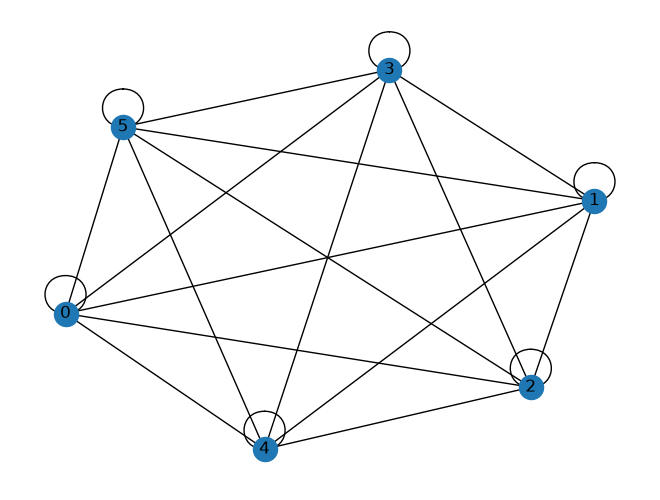

In [33]:
g = torch_geometric.utils.to_networkx(G, to_undirected=True)
nx.draw(g, with_labels=True)

# Build torch_geometric dataset from examples

In [34]:
# https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html#frequently-asked-questions
# just create a DataLoader starting from the list of example Data
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# it actually trains better (as in lower loss) with a batch_size of 1
loader = DataLoader(data_list, batch_size=4)

# Build NN

In [35]:
# https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html
# https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html
# https://colab.research.google.com/github/Alireza-Akhavan/graph-neural-network/blob/main/07-Graph_Classification_pyg.ipynb#scrollTo=CN3sRVuaQ88l
# https://khairulislam.github.io/GNN/pages/graph/Graph_Classification.html

from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool

import lightning as L

class GCN(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        # All policies consist of 3 hidden layers, with 64 hidden units each and ReLU activation.
        # For attention policies, the number of attention heads were set to 1.
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 64)
        self.lin = Linear(64, N*2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        # Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        x = self.lin(x)

        # print()
        # print("pre softmax ", x, x.shape)

        # The output of the GNN policy is K + L dimensional, reshaped into K and L dimensional outputs
        objects = x[:, :N]
        goals = x[:, N:]

        # print("slice")
        # print()
        # print(objects, objects.shape)
        # print(goals, goals.shape)

        # and is then passed through a softmax function to generate a K-dimensional cateagorial distribution
        # depicting the picking probabilities of objects. 
        # The object with the highest predicted probability is the output of the GNN
        # return (F.softmax(objects, dim=0), F.softmax(goals, dim=0))
        # (cross entropy loss) The input is expected to contain the unnormalized logits for each class (which do not need to be positive or sum to 1, in general)
        return objects, goals

    def training_step(self, batch, batch_idx):
        out = self(batch)
        # (cross entropy loss) The target that this criterion expects should contain either: Class indices in the range [0,C)
        classes = batch.y.reshape(-1, 2) # always to classes for the labels (selected object, selected goal)

        # print("Out/batch")
        # print(out[0], out[0].shape)
        # print(out[1], out[1].shape)
        # print(classes, classes.shape)
        # print(classes[0], out[0])
        # print(classes[1], out[1])

        # Compute the loss and its gradients
        # error in taking this splice with batch_size > 1
        l1 = F.cross_entropy(out[0], classes[:, 0])
        # print("l1", out[0], data.y[0])
        l2 = F.cross_entropy(out[1], classes[:, 1])
        # print("l2", out[1], data.y[1])
        loss = l1+l2
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.01)

model = GCN().to(device)
model.train()

trainer = L.Trainer(max_epochs=100, accelerator="gpu")
trainer.fit(model, loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type    | Params | Mode  | FLOPs
--------------------------------------------------
0 | conv1 | GCNConv | 384    | train | 0    
1 | conv2 | GCNConv | 4.2 K  | train | 0    
2 | conv3 | GCNConv | 4.2 K  | train | 0    
3 | lin   | Linear  | 390    | train | 0    
--------------------------------------------------
9.1 K     Trainable params
0         Non-trainable params
9.1 K     Total params
0.036     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0 

Epoch 0:  32%|███▏      | 22/68 [00:00<00:00, 115.83it/s, v_num=64]

/home/emamaker/university/Università/magistrale/anno-2/semestre-1/nn/project/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 24. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 17:  97%|█████████▋| 66/68 [00:00<00:00, 124.12it/s, v_num=64, train_loss=2.79e-6]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1